# Hyperparameter Optimization

Optimize model hyperparameters with Optuna.

In [1]:
import sys; sys.path.insert(0, '..')
from src import suppress_logs; suppress_logs()

import torch
torch.set_float32_matmul_precision('medium')

from pytorch_lightning import seed_everything
from src.data import GestureDataModule
from src.models import BiLSTMModule, TransformerModule
from src.optimization import OptunaObjective, BiLSTMSearchSpace, TransformerSearchSpace, create_study
from src.visualization import plot_optuna_comparison, print_results_table

/home/marcantoniolopez/Documenti/github/dylem-grid/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
N_TRIALS = 100          # Trials per model
MAX_EPOCHS = 50        # Max epochs per trial
PATIENCE = 15
USE_CV = True          # Use cross-validation
N_FOLDS = 5            # Folds for CV
DATA_PATH = None       # Auto-download from HuggingFace
SEED = 42

seed_everything(SEED)
print(f'Optimization: {N_TRIALS} trials, {MAX_EPOCHS} epochs, CV={USE_CV}')

Seed set to 42


Optimization: 100 trials, 50 epochs, CV=True


In [3]:
dm = GestureDataModule(data_path=DATA_PATH, seed=SEED)

MODELS = {
    'bilstm': (BiLSTMModule, BiLSTMSearchSpace()),
    'transformer': (TransformerModule, TransformerSearchSpace())
}

## Run Optimization

In [ ]:
studies = {}
best_params = {}

for name, (model_class, search_space) in MODELS.items():
    print(f'\n{"="*60}\nOptimizing {name.upper()}\n{"="*60}')
    
    # Create study (Optuna logs suppressed by set_verbosity)
    study = create_study(f'{name}_opt')
    objective = OptunaObjective(model_class, dm, search_space, USE_CV, N_FOLDS, MAX_EPOCHS, PATIENCE)
    
    # Run optimization (Lightning logs suppressed by rank_zero logger config)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    
    studies[name] = study
    best_params[name] = study.best_trial.params
    
    print(f'Best accuracy: {study.best_value:.4f}')
    print(f'Best params: {study.best_trial.params}')


Optimizing BILSTM


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.821344:   9%|▉         | 9/100 [13:48<2:20:33, 92.68s/it]

## Results Comparison

In [ ]:
print('\n' + '='*60 + '\nOPTIMIZATION RESULTS\n' + '='*60)
for name, study in studies.items():
    print(f'{name.upper()}: {study.best_value:.4f}')
    for k, v in study.best_trial.params.items():
        print(f'  {k}: {v}')
    print()


OPTIMIZATION RESULTS
BILSTM: 0.6767
  hidden_size: 256
  num_layers: 2
  learning_rate: 0.004963461194543619
  dropout: 0.31317746547059355
  weight_decay: 8.58255796641142e-05
  optimizer: nadam

TRANSFORMER: 0.7759
  d_model: 64
  nhead: 8
  num_layers: 3
  dim_feedforward: 64
  learning_rate: 0.0003555578974733103
  dropout: 0.19446460902283388
  weight_decay: 0.00025473563917431305
  optimizer: adam



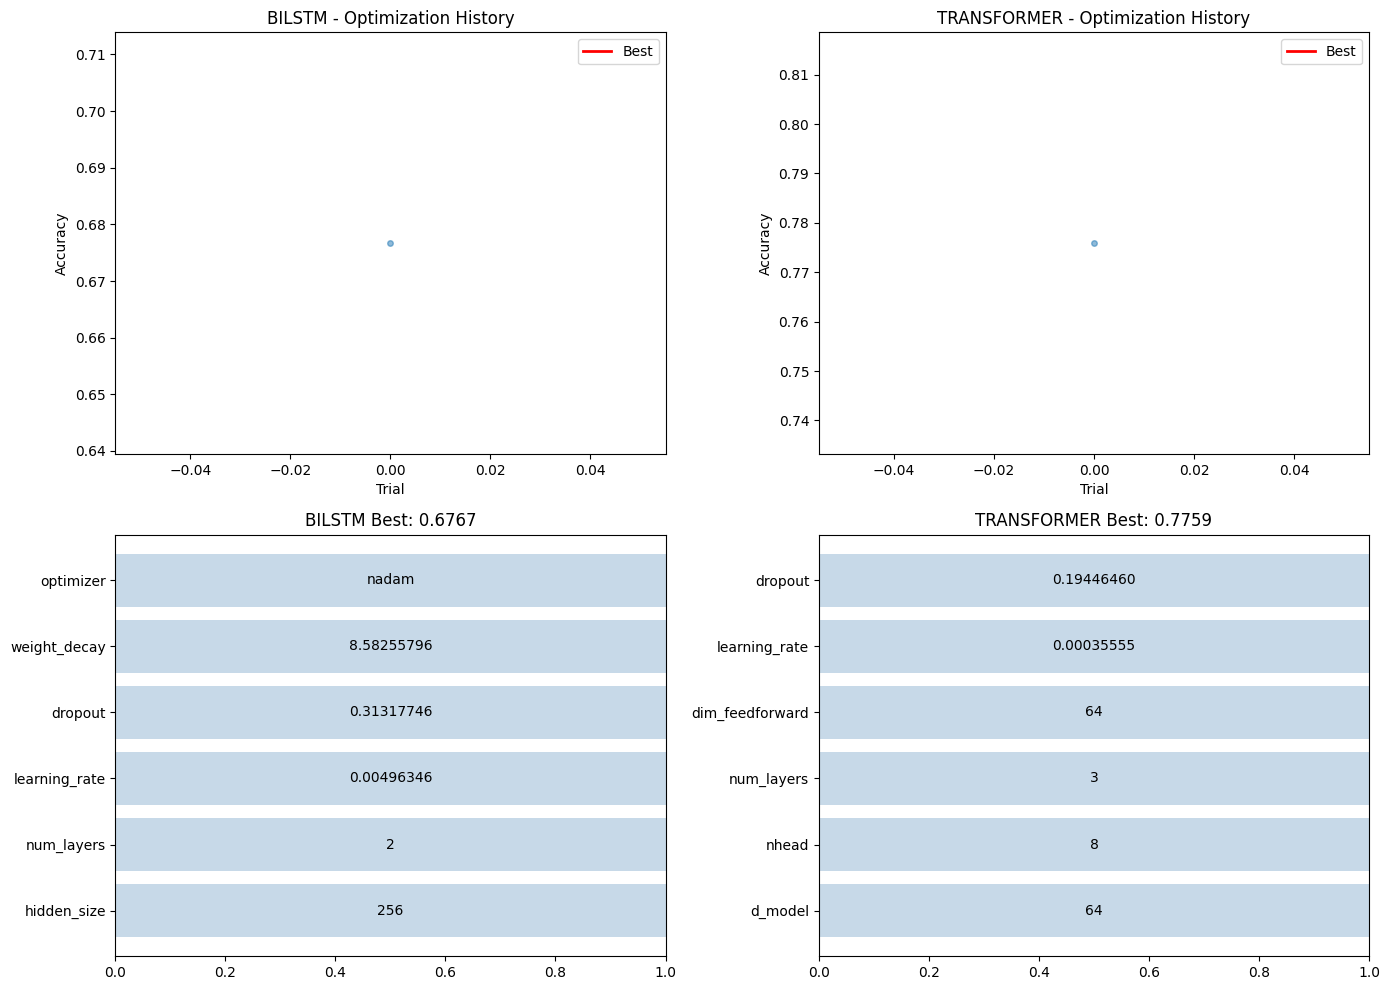

In [ ]:
fig = plot_optuna_comparison(studies)
fig.savefig('../plots/optuna_comparison.png', dpi=150)

## Optuna Visualizations

In [ ]:
from optuna.visualization import plot_optimization_history, plot_param_importances

for name, study in studies.items():
    print(f'\n{name.upper()} Optimization History:')
    display(plot_optimization_history(study))


BILSTM Optimization History:



TRANSFORMER Optimization History:


In [ ]:
for name, study in studies.items():
    completed = [t for t in study.trials if t.state.name == 'COMPLETE']
    if len(completed) >= 10:
        print(f'\n{name.upper()} Parameter Importance:')
        display(plot_param_importances(study))

## Save Results

In [ ]:
import json, joblib
from pathlib import Path

Path('../results/optuna').mkdir(parents=True, exist_ok=True)

for name, study in studies.items():
    joblib.dump(study, f'../results/optuna/{name}_study.pkl')
    with open(f'../results/optuna/{name}_best_params.json', 'w') as f:
        json.dump({'best_accuracy': study.best_value, 'params': study.best_trial.params}, f, indent=2)

print('Studies saved to ../results/optuna/')
print('\nCopy these params to 02_training.ipynb for final training!')

Studies saved to ../results/optuna/

Copy these params to 02_training.ipynb for final training!
